# SIFT + Bag of Visual Words

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install mtcnn -q

import cv2
import os, sys, joblib
from sklearn.model_selection import train_test_split
from skimage import img_as_ubyte, color
from sklearn.cluster import MiniBatchKMeans
from sklearn import svm, metrics
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

GOOGLE_DRIVE_PATH_AFTER_MYDRIVE = 'CW_Folder_UG'
GOOGLE_DRIVE_PATH = os.path.join('drive', 'My Drive', GOOGLE_DRIVE_PATH_AFTER_MYDRIVE)
print(os.listdir(GOOGLE_DRIVE_PATH))
CODE_PATH = os.path.abspath(f'{GOOGLE_DRIVE_PATH}/Code')

if CODE_PATH not in sys.path:
    sys.path.insert(0, CODE_PATH)

print(CODE_PATH)
print(os.path.exists(os.path.join(CODE_PATH, "utils.py")))

MODELS_DIR = os.path.join(GOOGLE_DRIVE_PATH, 'Models')
os.makedirs(MODELS_DIR, exist_ok=True)



import zipfile
from pathlib import Path

src = Path(GOOGLE_DRIVE_PATH) / "CW_Dataset"
dst = Path(GOOGLE_DRIVE_PATH) / "CW_Dataset.zip"

if not dst.exists():
  with zipfile.ZipFile(dst, "w", zipfile.ZIP_DEFLATED) as zf:
      for file in src.rglob("*"):
          zf.write(file, arcname=file.relative_to(src.parent))
  print(f"Created: {dst}")

!cp '{GOOGLE_DRIVE_PATH}/CW_Dataset.zip' .
!yes|unzip -q CW_Dataset.zip
!rm CW_Dataset.zip

LOCAL_ROOT = '/content'



from utils import *

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 49.6 MB/s eta 0:00:00
['Code', 'Models', 'CW_Dataset', 'Personal_Dataset', 'CW_Dataset.zip', 'Personal_Dataset.zip', 'test_function.ipynb']
/content/drive/My Drive/CW_Folder_UG/Code
True


In [2]:
train_paths_all, train_labels_all, test_paths, test_labels = load_dataset(LOCAL_ROOT)

train_paths, val_paths, y_train, y_val = make_train_val_split(
    train_paths_all, train_labels_all, test_size=0.15)
y_train, y_val, y_test = np.array(y_train), np.array(y_val), np.array(test_labels)
print(f'Train:{len(train_paths)}  Val:{len(val_paths)}  Test:{len(test_paths)}')
CLASS_NAMES = [AGE_LABELS[i] for i in range(4)]

Train: 13300 images
Test: 850 images
Train:11305  Val:1995  Test:850


In [3]:
import warnings; warnings.filterwarnings('ignore')

# Grid search over n_codewords on a 2000-sample subset
GRID_N = 2000
rng = np.random.default_rng(SEED)
gs_idx = rng.choice(len(train_paths), size=GRID_N, replace=False)
gs_paths = [train_paths[i] for i in gs_idx]
gs_y = y_train[gs_idx]

sift = cv2.SIFT_create()

print(f"{'n_codewords':>12} {'val acc':>10}")
best_nc, best_acc = None, -1
for nc in [50, 100, 150, 200]:
    # Descriptor collection (Lab_06 cell 21)
    des_list, y_list = [], []
    for p, lbl in zip(gs_paths, gs_y):
        img = img_as_ubyte(color.rgb2gray(read_rgb(p)))
        kp, des = sift.detectAndCompute(img, None)
        if des is not None:
            des_list.append(des)
            y_list.append(lbl)
    des_array = np.vstack(des_list)

    # Codebook (Lab_06 cell 24)
    batch_size = des_array.shape[0] // 4
    km = MiniBatchKMeans(n_clusters=nc, batch_size=batch_size, n_init='auto', random_state=SEED).fit(des_array)

    # Histograms (Lab_06 cell 26)
    hist_list = []
    for des in des_list:
        hist = np.zeros(nc)
        idx = km.predict(des)
        for j in idx:
            hist[j] = hist[j] + (1 / len(des))
        hist_list.append(hist)
    X_gs = np.vstack(hist_list)

    X_tr, X_va, y_tr, y_va = train_test_split(X_gs, y_list, test_size=0.2, random_state=SEED)
    clf = svm.SVC(kernel='rbf', class_weight='balanced')
    clf.fit(X_tr, y_tr)
    acc = accuracy_score(y_va, clf.predict(X_va))
    print(f'{nc:>12} {acc:>10.4f}')
    if acc > best_acc:
        best_acc, best_nc = acc, nc

print()
print(f'Best n_codewords: {best_nc}')

 n_codewords    val acc
          50     0.4500
         100     0.4425
         150     0.5000
         200     0.4825

Best n_codewords: 150


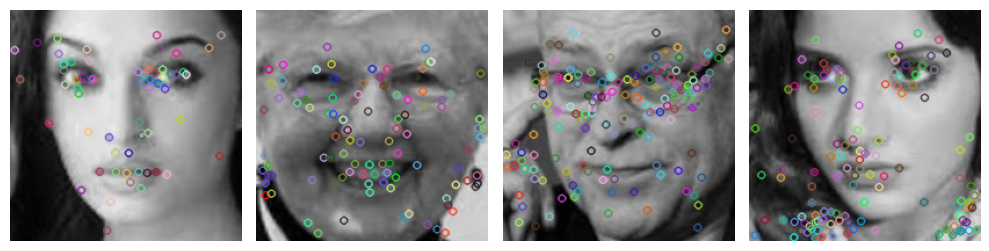


SIFT extraction time: 211.9s


In [4]:
import time

t0 = time.time()

# Reference: Lab_06_Solved.ipynb (1: Image classification with Bag of Visual Words)

# Initiate SIFT detector
sift = cv2.SIFT_create()

# Create empty lists for feature descriptors and labels
des_list = []
y_train_list = []

fig, ax = plt.subplots(1, 4, figsize=(10, 8), sharey=True)

for i in range(len(train_paths)):
    # Identify keypoints and extract descriptors with SIFT
    img = img_as_ubyte(color.rgb2gray(read_rgb(train_paths[i])))
    kp, des = sift.detectAndCompute(img, None)

    # Show results for first 4 images
    if i < 4:
        img_with_SIFT = cv2.drawKeypoints(img, kp, img)
        ax[i].imshow(img_with_SIFT)
        ax[i].set_axis_off()

    # Append list of descriptors and label to respective lists
    if des is not None:
        des_list.append(des)
        y_train_list.append(y_train[i])

fig.tight_layout()
plt.show()

# Convert to array for easier handling
des_array = np.vstack(des_list)

sift_time = time.time() - t0
print()
print(f'SIFT extraction time: {sift_time:.1f}s')

In [5]:
# Reference: Lab_06_Solved.ipynb (1: Image classification with Bag of Visual Words)

# Number of centroids/codewords: from grid search
k = best_nc

# Use MiniBatchKMeans for faster computation and lower memory usage
batch_size = des_array.shape[0] // 4
t0 = time.time()
kmeans = MiniBatchKMeans(n_clusters=k, batch_size=batch_size, n_init='auto', random_state=SEED).fit(des_array)
kmeans_time = time.time() - t0
print(f'KMeans fitting time: {kmeans_time:.1f}s')

KMeans fitting time: 126.8s


In [6]:
# Reference: Lab_06_Solved.ipynb (1: Image classification with Bag of Visual Words)

# Convert descriptors into histograms of codewords for each image
hist_list = []
idx_list = []

for des in des_list:
    hist = np.zeros(k)

    idx = kmeans.predict(des)
    idx_list.append(idx)
    for j in idx:
        hist[j] = hist[j] + (1 / len(des))
    hist_list.append(hist)

hist_array = np.vstack(hist_list)

In [7]:
from sklearn.pipeline import Pipeline

# Reference: Lab_06_Solved.ipynb (1: Image classification with Bag of Visual Words)

# Create a classifier: a support vector classifier
t0 = time.time()
classifier = svm.SVC(kernel='rbf', class_weight='balanced')
classifier.fit(hist_array, y_train_list)
svm_time = time.time() - t0
print(f'SVM training time: {svm_time:.1f}s')
print(f'Total training time: {sift_time + kmeans_time + svm_time:.1f}s')

# Wrap kmeans + classifier into a pipeline so inference needs only raw paths
encoder = SIFTBoVWTransformer(n_codewords=k, crop_face=True)
encoder.kmeans_ = kmeans  # inject the already-fitted codebook

pipeline_bovw = Pipeline([('encoder', encoder), ('clf', classifier)])
joblib.dump(pipeline_bovw, os.path.join(MODELS_DIR, 'model_2_rbf_svm.pkl'))

SVM training time: 37.8s
Total training time: 376.5s


['drive/My Drive/CW_Folder_UG/Models/model_2_rbf_svm.pkl']

In [8]:
mb = os.path.getsize(os.path.join(MODELS_DIR, 'model_2_rbf_svm.pkl')) / 1e6
print(f'SIFT + BoVW + RBF SVM  {mb:.2f} MB')

SIFT + BoVW + RBF SVM  17.28 MB


In [9]:
# Reference: Lab_06_Solved.ipynb (1: Image classification with Bag of Visual Words)

hist_list = []

for i in range(len(test_paths)):
    img = img_as_ubyte(color.rgb2gray(read_rgb(test_paths[i])))
    kp, des = sift.detectAndCompute(img, None)

    if des is not None:
        hist = np.zeros(k)
        idx = kmeans.predict(des)
        for j in idx:
            hist[j] = hist[j] + (1 / len(des))
        hist_list.append(hist)
    else:
        hist_list.append(None)

# Remove potential cases of images with no descriptors
idx_not_empty = [i for i, x in enumerate(hist_list) if x is not None]
hist_list = [hist_list[i] for i in idx_not_empty]
y_test = [y_test[i] for i in idx_not_empty]
hist_array = np.vstack(hist_list)

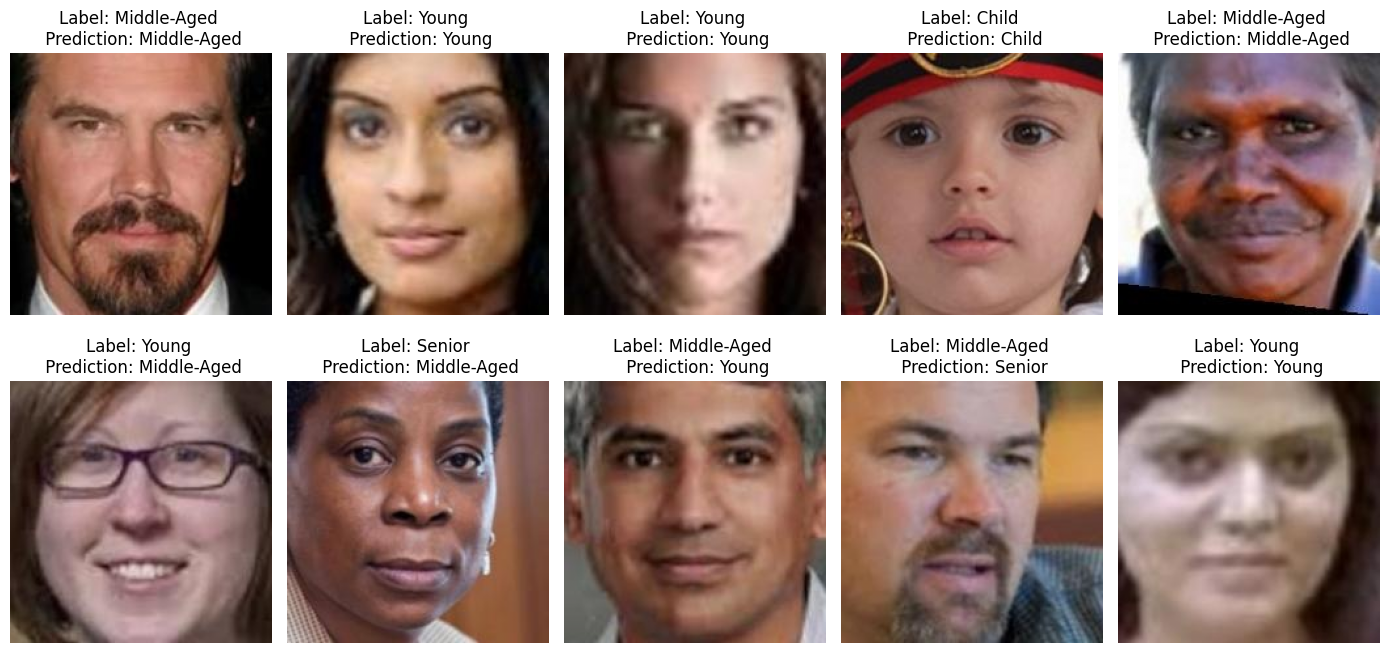

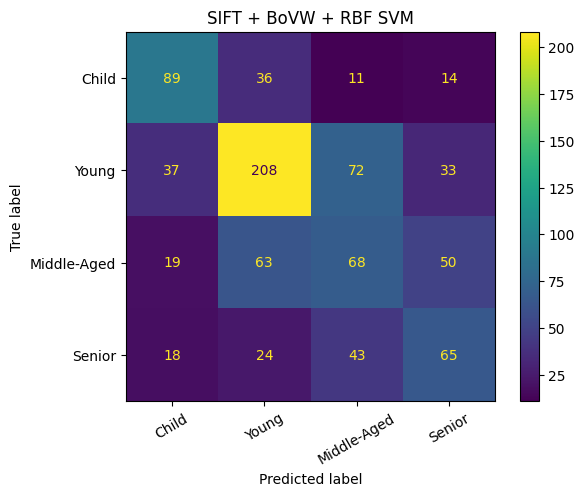

Classification report for classifier SVC(class_weight='balanced'):
                    precision    recall  f1-score   support

       Child       0.55      0.59      0.57       150
       Young       0.63      0.59      0.61       350
 Middle-Aged       0.35      0.34      0.35       200
      Senior       0.40      0.43      0.42       150

    accuracy                           0.51       850
   macro avg       0.48      0.49      0.49       850
weighted avg       0.51      0.51      0.51       850




In [10]:
# Reference: Lab_06_Solved.ipynb (1: Image classification with Bag of Visual Words)

CLASS_NAMES = [AGE_LABELS[i] for i in range(4)]
y_pred = classifier.predict(hist_array).tolist()

fig, axes = plt.subplots(2, 5, figsize=(14, 7), sharex=True, sharey=True)
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(read_rgb(test_paths[idx_not_empty[i]]))
    ax[i].set_title(f'Label: {AGE_LABELS[int(y_test[i])]} \n Prediction: {AGE_LABELS[int(y_pred[i])]}')
    ax[i].set_axis_off()
fig.tight_layout()
plt.show()

metrics.ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=CLASS_NAMES, xticks_rotation=30)
plt.title('SIFT + BoVW + RBF SVM')
plt.show()

print(f"""Classification report for classifier {classifier}:
      {metrics.classification_report(y_test, y_pred, target_names=CLASS_NAMES)}\n""")